# **Portfolio Forecast Demo: Simulate a Portfolio**

Backtests a five-stock portfolio over the past ten years, then forecasts its next 100 trading days.

1. Download 10 years of daily prices for five stocks.
2. Backtest a fixed-weight buy-and-hold portfolio with `simulate_buy_and_hold`.
3. Forecast the portfolio's value with `regime_switching_monte_carlo`.

## **Imports**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from portfolio_forecast.forecast import regime_switching_monte_carlo
from portfolio_forecast.performance import performance_report, simulate_buy_and_hold, statistical_report
from portfolio_forecast.plotting import plot_simulated_paths
from portfolio_forecast.utils import next_trading_dates

## **Obtaining Example Data**

`yf.download` returns every field (Close, High, Low, Open, Volume) for each ticker; `simulate_buy_and_hold` picks out the closes itself.

In [2]:
# Ten years of daily bars for five stocks from Yahoo Finance, adjusted for splits and dividends
tickers = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM']
data = yf.download(tickers, period='10y', interval='1d', auto_adjust=True, progress=False)

print(data.shape)
data['Close'].tail()

(2513, 25)


Ticker,AAPL,JNJ,JPM,MSFT,XOM
Date,,,,,
2026-09-18,336.130005,269.989990,349.670013,493.779999,163.539993
2026-09-21,338.980011,269.470001,352.040009,501.609985,158.300003
2026-09-22,339.750000,NaN,340.000000,498.000000,NaN
2026-09-23,337.019989,269.170013,337.529999,500.589996,161.229996
2026-09-24,336.089996,272.140015,336.549988,493.725006,164.294998


## **Buy-and-Hold Backtest**

The portfolio is bought at the first close and never rebalanced, so its weights drift with prices.

In [3]:
# Weights by ticker; they are normalized to sum to 1, and a ticker left out is not held
weights = {'AAPL': 0.30, 'MSFT': 0.25, 'JPM': 0.20, 'JNJ': 0.15, 'XOM': 0.10}

# The portfolio's value at every close, starting from $10,000
values, dates = simulate_buy_and_hold(data, weights, br0=10_000)
backtest = performance_report(values, dates, '1 day', display=True)


            PORTFOLIO PERFORMANCE REPORT            
----------------------------------------------------
  Total Time         :  2512 periods  (9.97 years)
  Calendar Span      :  3650 days
                      RETURNS                       
----------------------------------------------------
  Initial Bankroll   :     10000.00
  Final Bankroll     :     84392.00
  Total Return       :      743.92%
  CAGR               :       23.86%
----------------------------------------------------
  Actual Yearly Returns:
    - 2016            :       10.59%  (96 days)
    - 2017            :       32.96%  (365 days)
    - 2018            :        0.55%  (365 days)
    - 2019            :       56.68%  (365 days)
    - 2020            :       41.04%  (366 days)
    - 2021            :       38.29%  (365 days)
    - 2022            :      -21.06%  (365 days)
    - 2023            :       42.39%  (365 days)
    - 2024            :       23.68%  (366 days)
    - 2025            :       16.92%  (3

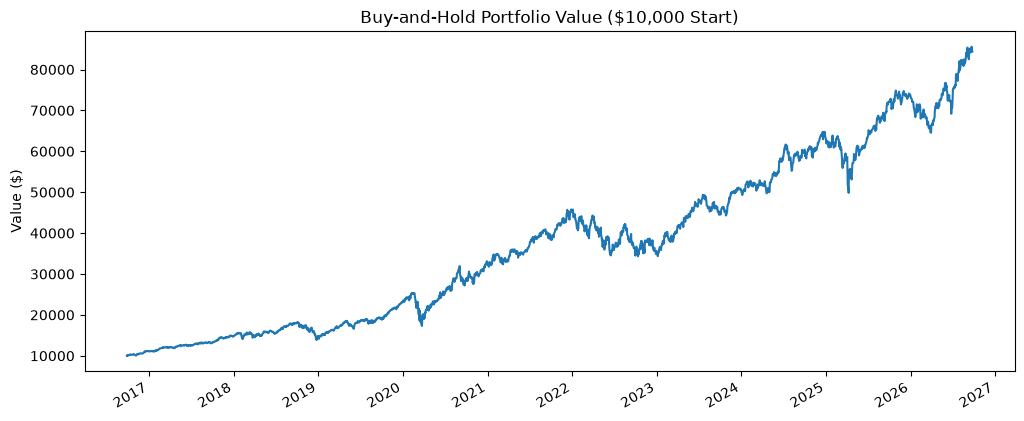

In [4]:
# The backtested value over the ten years
fig, ax = plt.subplots(figsize=(12, 5))
values.plot(ax=ax)
ax.set_title('Buy-and-Hold Portfolio Value ($10,000 Start)')
ax.set_ylabel('Value ($)')
plt.show()

## **Regime-Switching Forecast**

The backtested portfolio values are the history to forecast from. Each simulated path is a growth multiple of the last backtested value.

In [5]:
# n_regimes=None fits 1, 2, and 3 regimes and uses the lowest BIC;
# return_fit=True also returns the regime count, each count's BIC and a table of the regimes
sims, fit = regime_switching_monte_carlo(values, sim_length=100, n_sims=10000,
                                         random_state=np.random.default_rng(42), return_fit=True)
fit['Regimes']

1 regime(s) BIC: -14,343.90


2 regime(s) BIC: -15,203.35


3 regime(s) BIC: -15,334.08
Selected: 3 regime(s)
Regime 0: mean +0.1586%, vol 0.7375%, expected duration 51.2 periods
Regime 1: mean +0.0471%, vol 1.4785%, expected duration 28.9 periods
Regime 2: mean -0.5475%, vol 4.2858%, expected duration 9.1 periods


,Mean,Volatility,Expected Duration,Current Probability
Regime,,,,
0,0.001586,0.007375,51.216696,0.912542
1,0.000471,0.014785,28.863241,0.087057
2,-0.005475,0.042858,9.057652,0.000401


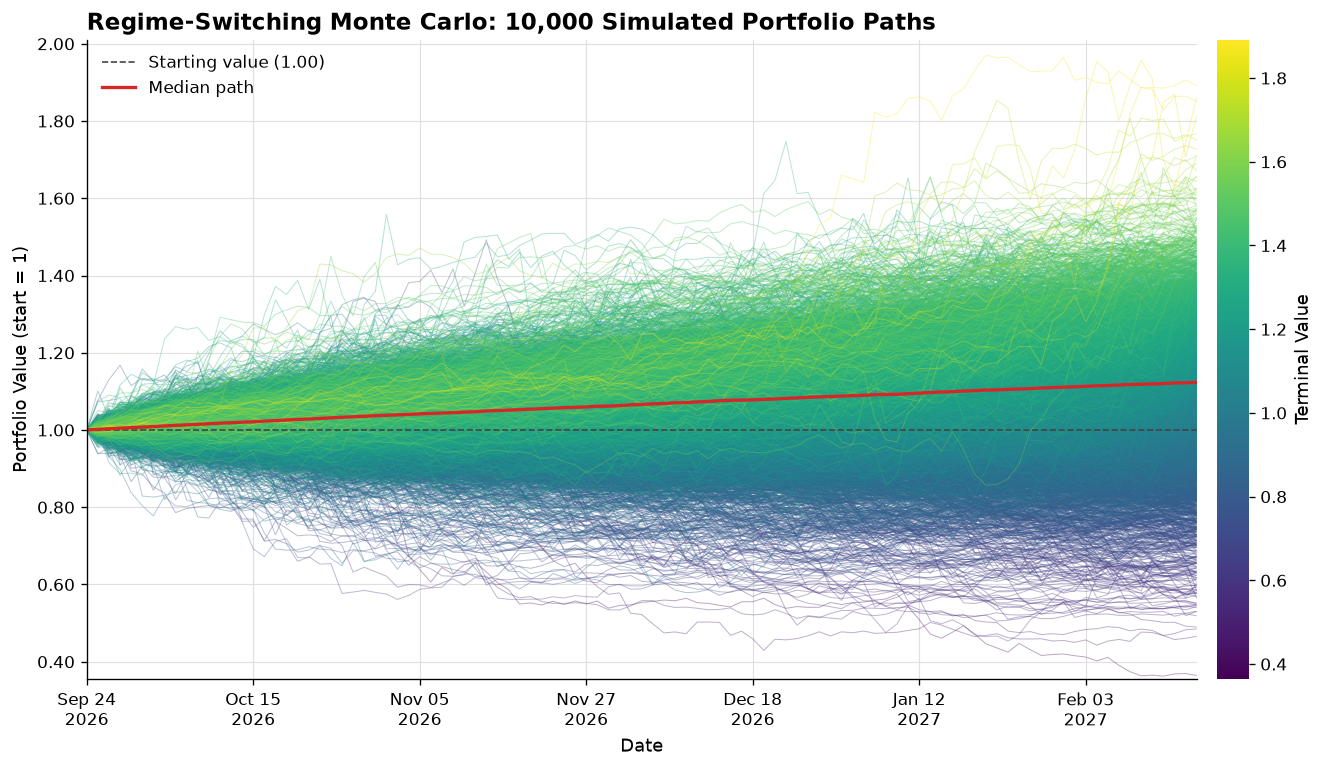

In [6]:
# Dates for the plot: the last backtested close (each path's starting value)
# followed by the next 100 trading days, matching sim_length=100 above
sim_dates = values.index[-1:].append(next_trading_dates(values.index, 100))

fig, ax = plot_simulated_paths(sims, method='Regime-Switching Monte Carlo', dates=sim_dates)
plt.show()

### **Statistical Report**

In [7]:
# Each metric's median and 95% interval across the simulated paths
forecast = statistical_report(sims, interval='1 day', confidence=0.95, dates=sim_dates, display=True)


                     SIMULATED PORTFOLIO STATISTICAL REPORT                     
--------------------------------------------------------------------------------
  Simulated Paths      : 10,000
  Horizon              :   100 periods  (0.40 years)
  Calendar Span        :   147 days
                                    RETURNS                                     
--------------------------------------------------------------------------------
                               Mean       Median                   95% interval
--------------------------------------------------------------------------------
  Final Bankroll       :       1.12         1.12                   [0.79, 1.40]
  Total Return         :     11.59%       12.34%              [-21.46%, 40.06%]
  CAGR                 :     36.42%       34.07%             [-45.60%, 133.74%]
                                      RISK                                      
------------------------------------------------------------------------

In [8]:
# The forecast in dollars: percentiles of the portfolio's value in 100 trading days
end_values = values.iloc[-1] * sims[:, -1]
pd.Series(end_values).quantile([0.05, 0.25, 0.5, 0.75, 0.95]).map('${:,.0f}'.format)

0.05     $71,953
0.25     $86,881
0.50     $94,804
0.75    $102,226
0.95    $113,652
dtype: object